<a href="https://colab.research.google.com/github/Millenes2/Millenes2/blob/main/Hash2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tabela Hash e Tratamento de Colisão**  -

Uma tabela de dispersão (ou tabela hash) é uma coleção de itens armazenados a partir da ideia de dispersão. Cada posição da tabela, denominada **índice**, pode guardar um item e começa a partir de 0. Inicialmente, a tabela de dispersão não contém nenhum item, então todos os índices estão vazios.

Na figura abaixo, foi incluído no **índice** 0 o item ***apple*** e assim sucessivamente, de forma que os itens fiquem dispersos e fáceis de serem encontradas.


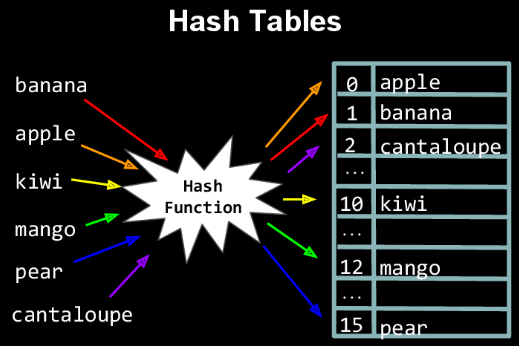

Fonte: https://medium.com/@edwin.cloud/hash-tables-simplified-93e378b7a3e8

**Questão 1**: Desenhe uma tabela de dispersão (*hash*) resultante da introdução dos valores 12, 24, 13, 44, 23, 17, 11, 33, 20, 16 e 5 em **posições** da tabela, usando a função de dispersão `h(k) = (2k + 5) % 11`. Caso existam colisões, elas deverão ser tratadas por encadeamento separado.

Em seguida, implemente a referida função em linguagem Python.


---




**Desenho da Tabela Hash**


0  -> []
1  -> [20]
2  -> []
3  -> []
4  -> [16, 5]
5  -> [44, 11, 33]
6  -> [17]
7  -> [12, 23]
8  -> []
9  -> [24, 13]
10 -> []

In [1]:
def h(k):
    return (2 * k + 5) % 11

Seja a definição abaixo para uma **Tabela Hash**. A definição é feita a partir de um **tamanho fixo** para a tabela, e mais **duas listas** para armazenar os índices gerados e os itens relacionados representando pares (chave,valor). As listas serão criadas com posições vazias e tamanho pré-definido.

In [3]:
# Criação de listas com posições vazias e tamanho pré-definido:
tam = 5
lista = [None] * tam
print(lista)

[None, None, None, None, None]


A **Tabela Hash** terá duas listas com posições vazias e tamanho pré-definido. Uma lista deve guardar os índices e outra os itens associados, ambos na mesma posição.

In [4]:
# Definição da Classe TabelaHash com tamanho pré-definido e listas vazias
class TabelaHash:
    def __init__(self, tam):
        self.tamanho = tam
        self.indice = [None] * self.tamanho    # lista vazia para o armazenamento das chaves (ou índices)
        self.item = [None] * self.tamanho      # lista vazia para o armazenamento dos valores (ou itens)

In [5]:
#Criação de uma tabela hash de tamanho 11
T = TabelaHash(11)
print(T.tamanho,"\n", T.indice,"\n", T.item)

11 
 [None, None, None, None, None, None, None, None, None, None, None] 
 [None, None, None, None, None, None, None, None, None, None, None]


A inserção na **Tabela Hash** deve ser feita de acordo com uma **função hash**, que determina um espalhamento, dentro da tabela. A seguir, uma função simples de espalhamento é criada, usando o **método da divisão** (ou resto da divisão). Este método garante que a posição gerada esteja dentro da tabela.

In [6]:
class TabelaHash:
    def __init__(self, tam):
        self.tamanho = tam
        self.indice = [None] * self.tamanho
        self.item = [None] * self.tamanho

    def funcao_hash(self, novo_indice, tamanho):
        return novo_indice % tamanho

In [7]:
# Criar tabela hash de tamanho 11 e usar a função_hash para saber em que posição o valor 18 (índice) seria armazenado
T = TabelaHash(11)
poshash = T.funcao_hash(18, T.tamanho)
print(poshash)

7


In [8]:
#O armazenamento se daria desta forma: (18, Adriana) na posição 7 (poshash) de ambas as listas.
T.indice[poshash] = 18
T.item[poshash] = "Adriana"
print(T.indice,"\n", T.item)

[None, None, None, None, None, None, None, 18, None, None, None] 
 [None, None, None, None, None, None, None, 'Adriana', None, None, None]


Teste a `função_hash` com outros valores. Como a `poshash` é calculada sempre a partir do resto da divisão por 11 (tamanho dado), ela será sempre entre 0 e 10.

A seguir, vamos incluir a **função de inserção** na Tabela Hash para as informações desejadas, que são pares (índice, item), ou chave-valor. Por exemplo, teríamos que incluir números de matrícula e alunos: `(356, "Maria"), (781, "Victor"), ....`

In [9]:
class TabelaHash:
    def __init__(self, tam):
        self.tamanho = tam
        self.indice = [None] * self.tamanho
        self.item = [None] * self.tamanho

    def funcao_hash(self, novo_indice, tamanho):
        return novo_indice % tamanho

    def insere(self, novo_indice, novo_item):
        pos_hash = self.funcao_hash(novo_indice, self.tamanho)
        self.indice[pos_hash] = novo_indice
        self.item[pos_hash] = novo_item


In [10]:
T = TabelaHash(11)
T.insere(356, "Maria")
T.insere(781, "Victor")
print(T.indice, "\n", T.item)

[781, None, None, None, 356, None, None, None, None, None, None] 
 ['Victor', None, None, None, 'Maria', None, None, None, None, None, None]


A função `insere` anterior não trata os casos de **colisão** (quando índices diferentes caem na mesma posição). O exemplo a seguir mostra o resultado da inserção quando três índices caem na mesma posição. São então sobrepostos, e apenas o último fica armazenado.

In [11]:
T = TabelaHash(11)
T.insere(356, "Maria")
T.insere(785, "Victor")
T.insere(224, "Caio")
print(T.indice, "\n", T.item)

[None, None, None, None, 224, None, None, None, None, None, None] 
 [None, None, None, None, 'Caio', None, None, None, None, None, None]


# **Tratamento de Colisão**

Para o tratamento dos casos de **colisão** teremos que decidir qual será a estratégia durante a inserção: encadeamento separado ou endereçamento aberto. Vamos utilizar o **endereçamento aberto com sondagem linear**, onde procuramos a próxima posição livre na Tabela Hash, caso a poshash gerada já esteja ocupada.

In [18]:
class TabelaHash:
    def __init__(self, tam):
        self.tamanho = tam
        self.indice = [None] * self.tamanho
        self.item = [None] * self.tamanho

    def funcao_hash(self, novo_indice, tamanho):
        return novo_indice % tamanho

    def funcao_novo_hash(self, hash_antigo, tamanho):    # nova posição hash usando sondagem linear
        return (hash_antigo+1) % tamanho

    def insere(self, novo_indice, novo_item):
        pos_hash = self.funcao_hash(novo_indice, self.tamanho)

        if self.indice[pos_hash] == None:
            self.indice[pos_hash] = novo_indice
            self.item[pos_hash] = novo_item
        else:                                            # programação da sondagem linear
            nova_pos_hash = self.funcao_novo_hash(pos_hash, self.tamanho)
            while self.indice[nova_pos_hash] != None:
                 nova_pos_hash = self.funcao_novo_hash(nova_pos_hash, self.tamanho)
            self.indice[nova_pos_hash] = novo_indice
            self.item[nova_pos_hash] = novo_item



In [19]:
# Testando as funções 'funcao_hash' e 'funcao_novo_hash'
T = TabelaHash(11)
pos_hash = T.funcao_hash(356,11)
nova_pos = T.funcao_novo_hash(pos_hash,11)
print (pos_hash, nova_pos)

4 5


In [ ]:
# Testando os três casos de colisão identificados anteriormente.
# Com a sondagem linear, os itens serão armazenados nas próximas posições livres.
T = TabelaHash(11)
T.insere(356, "Maria")
T.insere(785, "Victor")
T.insere(224, "Caio")
print(T.indice, "\n", T.item)

**Questão 2**: Dados os valores 2341, 4234, 2839, 430, 22, 397, 3920, uma Tabela Hash de tamanho 7, e a função de espalhamento `h(x) = x % 7`, mostre a Tabela Hash resultante depois de inserir os valores na ordem dada usando a **sondagem linear**.


---



Resposta:

0 -> 397
1 -> 22
2 -> 3920
3 -> 2341
4 -> 2839
5 -> 430
6 -> 4234


**Questão 3**: Inclua na classe `TabelaHash` uma função de `busca`, tal que, dado um índice, o item correspondente seja devolvido.

**Dica**: a função `busca` deve ter o mesmo comportamento que a função `insere`. Caso a posição de busca não contenha o índice desejado, deve-se procurar nas próximas posições, utilizando-se também a **sondagem linear**.


---



In [20]:
class TabelaHash:
    def __init__(self, tam):
        self.tamanho = tam
        self.indice = [None] * self.tamanho
        self.item = [None] * self.tamanho

    def funcao_hash(self, novo_indice, tamanho):
        return novo_indice % tamanho

    def funcao_novo_hash(self, hash_antigo, tamanho):
        return (hash_antigo + 1) % tamanho

    def insere(self, novo_indice, novo_item):
        pos_hash = self.funcao_hash(novo_indice, self.tamanho)

        if self.indice[pos_hash] is None:
            self.indice[pos_hash] = novo_indice
            self.item[pos_hash] = novo_item
        else:
            nova_pos_hash = self.funcao_novo_hash(pos_hash, self.tamanho)

            while self.indice[nova_pos_hash] is not None:
                nova_pos_hash = self.funcao_novo_hash(nova_pos_hash, self.tamanho)

            self.indice[nova_pos_hash] = novo_indice
            self.item[nova_pos_hash] = novo_item

    def busca(self, chave):
        pos_hash = self.funcao_hash(chave, self.tamanho)
        pos_inicial = pos_hash

        while self.indice[pos_hash] is not None:
            if self.indice[pos_hash] == chave:
                return self.item[pos_hash]

            pos_hash = self.funcao_novo_hash(pos_hash, self.tamanho)

            if pos_hash == pos_inicial:
                break

        return None

In [21]:
T = TabelaHash(11)
T.insere(356, "Maria")
T.insere(785, "Victor")
T.insere(224, "Caio")

print(T.indice)
print(T.item)
print(T.busca(356))
print(T.busca(785))
print(T.busca(224))
print(T.busca(999))

[None, None, None, None, 356, 785, 224, None, None, None, None]
[None, None, None, None, 'Maria', 'Victor', 'Caio', None, None, None, None]
Maria
Victor
Caio
None
